# LLM Fine-Tuning Methods — Head-to-Head on One Task

> Six ways to move a model's weights — full fine-tuning, BitFit, LoRA, IA3, prompt tuning, prefix tuning — trained on the *same* task with the *same* step budget, followed by a from-scratch DPO implementation that removes an unwanted behavior no supervised example ever flagged. Runs entirely on CPU with distilgpt2.

See [finetuning_methods_survey.md](finetuning_methods_survey.md) for the full survey (taxonomy, math, method-selection guide).

The experiment holds the **objective** fixed (a supervised instruction task) and sweeps the **parameter axis**:

| Method | Family | What moves |
|---|---|---|
| Full FT | — | all 82M weights |
| BitFit | selective | bias terms only |
| LoRA | reparameterization | low-rank deltas on attention + MLP |
| IA3 | additive (rescaling) | per-channel scaling vectors |
| Prompt tuning | additive (soft prompt) | 20 virtual input embeddings |
| Prefix tuning | additive (soft prompt) | 20 virtual KV vectors per layer |

Then it swaps the objective (SFT → DPO) while keeping the parameters fixed (LoRA).

## 1. Setup — the shared task

We need a task where success is *measurable* (exact match, not vibes) and learnable within ~120 CPU steps: converting structured sensor-style data into a fixed-template report.

```
prompt:  data: time=07:30 temp=15 sky=cloudy\nreport:
target:  At 07:30 it is 15 degrees and cloudy.
```

This is a *behavior* task (schema + value copying), i.e. exactly the kind of problem fine-tuning is for. Train/eval split is by slot **combination**, so exact match on eval proves generalization over the template, not memorization.

In [1]:
import copy
import gc
import random
import time
import warnings

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
import transformers
from peft import (get_peft_model, LoraConfig, IA3Config, PromptTuningConfig,
                  PrefixTuningConfig, PromptTuningInit, TaskType)

transformers.utils.logging.set_verbosity_error()
transformers.utils.logging.disable_progress_bar()
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

MODEL = "distilbert/distilgpt2"
STEPS = 120
BATCH = 8

tok = AutoTokenizer.from_pretrained(MODEL)
tok.pad_token = tok.eos_token
tok.padding_side = "right"

def load_base():
    return AutoModelForCausalLM.from_pretrained(MODEL)

print(f"torch {torch.__version__} | transformers {transformers.__version__}")
print(f"threads: {torch.get_num_threads()}")

/home/jetson/w/ML_report/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.12.0+cu130 | transformers 5.10.2
threads: 16


In [2]:
SKIES = ["sunny", "cloudy", "rainy", "foggy", "windy", "snowy"]
TAIL = " Stay alert and drive safely at all times!"   # used in the DPO section

def make_example(t, temp, sky):
    prompt = f"data: time={t} temp={temp} sky={sky}\nreport:"
    target = f" At {t} it is {temp} degrees and {sky}."
    return prompt, target

def build_data(n_train=160, n_eval=24):
    combos = [(f"{h:02d}:{m:02d}", temp, sky)
              for h in range(0, 24, 2) for m in (0, 30)
              for temp in range(0, 35, 5) for sky in SKIES]
    random.shuffle(combos)                      # split by combination -> no overlap
    train = [make_example(*c) for c in combos[:n_train]]
    evals = [make_example(*c) for c in combos[n_train:n_train + n_eval]]
    return train, evals

train_data, eval_data = build_data()
print(f"train {len(train_data)} | eval {len(eval_data)} (held-out slot combinations)")
p, t = train_data[0]
print(f"prompt: {p!r}")
print(f"target: {t!r}")

train 160 | eval 24 (held-out slot combinations)
prompt: 'data: time=02:00 temp=0 sky=cloudy\nreport:'
target: ' At 02:00 it is 0 degrees and cloudy.'


## 2. Shared harness — prompt masking, training loop, evaluation

Three pieces every method reuses (so the only variable is *which parameters move*):

- **`encode_batch`** — tokenizes prompt+target, sets prompt-token labels to `-100` (**prompt masking**: loss only on response tokens) and appends **EOS** to every target (so the model learns to stop). These are pitfalls #2 and #4 in the survey.
- **`train_sft`** — plain AdamW loop over `requires_grad` parameters, identical steps/batch for all methods. Only the learning rate differs per method — LoRA wants ~10x full-FT lr, soft prompts ~100x (pitfall #5).
- **evaluation** — masked eval loss on held-out combinations, plus **greedy-decode exact match**: fine-tuning is judged by the task metric, not training loss (pitfall #6).

In [3]:
def encode_batch(pairs, tail_flags=None):
    """Tokenize (prompt, target) pairs with prompt-masked labels and EOS."""
    enc, max_len = [], 0
    for i, (p, t) in enumerate(pairs):
        if tail_flags is not None and tail_flags[i]:
            t = t + TAIL
        pi = tok(p, add_special_tokens=False)["input_ids"]
        ti = tok(t, add_special_tokens=False)["input_ids"] + [tok.eos_token_id]
        enc.append((pi, ti))
        max_len = max(max_len, len(pi) + len(ti))
    input_ids, labels, attn = [], [], []
    for pi, ti in enc:
        ids, lab = pi + ti, [-100] * len(pi) + ti
        pad = max_len - len(ids)
        input_ids.append(ids + [tok.eos_token_id] * pad)
        labels.append(lab + [-100] * pad)                 # padding also masked
        attn.append([1] * len(ids) + [0] * pad)
    return torch.tensor(input_ids), torch.tensor(labels), torch.tensor(attn)


def train_sft(model, data, steps=STEPS, bs=BATCH, lr=1e-3, tail_prob=0.0, log_every=30):
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr)
    model.train()
    rng = random.Random(0)          # same batch order for every method
    losses = []
    for step in range(steps):
        batch = rng.sample(data, bs)
        flags = [rng.random() < tail_prob for _ in range(bs)] if tail_prob else None
        ids, lab, attn = encode_batch(batch, flags)
        out = model(input_ids=ids, attention_mask=attn, labels=lab)
        out.loss.backward(); opt.step(); opt.zero_grad()
        losses.append(out.loss.item())
        if (step + 1) % log_every == 0:
            print(f"  step {step+1:3d}/{steps}  loss {np.mean(losses[-10:]):.4f}")
    return losses


@torch.no_grad()
def masked_eval_loss(model, data, bs=BATCH):
    model.eval()
    tot, n = 0.0, 0
    for i in range(0, len(data), bs):
        ids, lab, attn = encode_batch(data[i:i + bs])
        out = model(input_ids=ids, attention_mask=attn, labels=lab)
        k = (lab != -100).sum().item()
        tot += out.loss.item() * k; n += k
    return tot / n


@torch.no_grad()
def evaluate_generation(model, data, max_new=24):
    """Greedy decode one prompt at a time; return exact-match rate, tail rate, generations."""
    model.eval()
    hits, tails, gens = 0, 0, []
    for p, t in data:
        enc = tok(p, return_tensors="pt", add_special_tokens=False)
        out = model.generate(**enc, max_new_tokens=max_new, do_sample=False,
                             pad_token_id=tok.eos_token_id)
        gen = tok.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)
        gen = gen.split("\n")[0].strip()
        gens.append(gen)
        hits += int(gen == t.strip() or gen.startswith(t.strip()))
        tails += int("Stay alert" in gen)
    return hits / len(data), tails / len(data), gens


results = {}

def run_method(name, model, lr, steps=STEPS):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    t0 = time.time()
    losses = train_sft(model, train_data, steps=steps, lr=lr)
    train_time = time.time() - t0
    eval_loss = masked_eval_loss(model, eval_data)
    em, _, gens = evaluate_generation(model, eval_data)
    results[name] = dict(trainable=trainable, losses=losses, eval_loss=eval_loss,
                         em=em, time=train_time)
    print(f"{name}: trainable {trainable:,} ({100 * trainable / total:.3f}%) | "
          f"eval loss {eval_loss:.4f} | exact match {em:.2f} | {train_time:.0f}s")
    print(f"  sample: {gens[0]!r}")

print("harness ready")

harness ready


## 3. Zero-shot baseline

What does the base model do with our prompt before any weights move? distilgpt2 is a raw next-token predictor — expect free-associated continuation, not a report.

In [4]:
model = load_base()
eval_loss = masked_eval_loss(model, eval_data)
em, _, gens = evaluate_generation(model, eval_data)
results["zero-shot"] = dict(trainable=0, losses=[], eval_loss=eval_loss, em=em, time=0.0)
print(f"zero-shot: eval loss {eval_loss:.4f} | exact match {em:.2f}")
print(f"  sample: {gens[0]!r}")
del model; gc.collect();

zero-shot: eval loss 4.0577 | exact match 0.00
  sample: 'time=14:30 temp=5 sky=foggy'


## 4. Full fine-tuning — the 100% baseline

All 82M parameters move with plain backprop (lr 5e-5, the classic full-FT range). This is the quality ceiling the PEFT methods are measured against — and, at 7B+ scale, the option that costs ~16 bytes/param of GPU memory (survey section 2).

In [5]:
model = load_base()
run_method("full FT", model, lr=5e-5)
del model; gc.collect();

  step  30/120  loss 0.0201


  step  60/120  loss 0.0014


  step  90/120  loss 0.0010


  step 120/120  loss 0.0004


full FT: trainable 81,912,576 (100.000%) | eval loss 0.0000 | exact match 1.00 | 74s
  sample: 'At 14:30 it is 5 degrees and foggy.'


## 5. BitFit — selective family

Train **bias terms only** (~0.06% of parameters), by freezing everything whose name doesn't end in `bias`. No library needed — selective methods are just `requires_grad` surgery. BitFit doubles as a diagnostic: if it solves your task, the base model already had the capability and barely needed adapting.

In [6]:
model = load_base()
for name, p in model.named_parameters():
    p.requires_grad_(name.endswith("bias"))
run_method("BitFit", model, lr=1e-3)
del model; gc.collect();

  step  30/120  loss 0.2944


  step  60/120  loss 0.0473


  step  90/120  loss 0.0232


  step 120/120  loss 0.0123


BitFit: trainable 51,456 (0.063%) | eval loss 0.0007 | exact match 1.00 | 39s
  sample: 'At 14:30 it is 5 degrees and foggy.'


## 6. LoRA — reparameterization family

Low-rank deltas $W' = W + \frac{\alpha}{r}BA$ trained in parallel with frozen weights, mergeable at inference (zero latency overhead). Config follows the survey's defaults: r=8, alpha=2r, **all linear modules** (attention `c_attn` + projections + MLP), lr ~10x full-FT's. Internals: [lora_qlora.md](lora_qlora.md).

In [7]:
lora_cfg = LoraConfig(task_type=TaskType.CAUSAL_LM, r=8, lora_alpha=16,
                      target_modules=["c_attn", "c_proj", "c_fc"], lora_dropout=0.05)
model = get_peft_model(load_base(), lora_cfg)
run_method("LoRA", model, lr=1e-3)
del model; gc.collect();

  step  30/120  loss 0.0347


  step  60/120  loss 0.0032


  step  90/120  loss 0.0008


  step 120/120  loss 0.0042


LoRA: trainable 589,824 (0.715%) | eval loss 0.0000 | exact match 1.00 | 46s
  sample: 'At 14:30 it is 5 degrees and foggy.'


## 7. IA3 — additive rescaling

Learned per-channel scaling vectors on keys/values and MLP activations — even fewer parameters than LoRA, and also mergeable (elementwise multiply into the weights). Its ceiling: it can only *rescale* existing feature directions, never add new ones. Typical lr is higher than LoRA's.

In [8]:
ia3_cfg = IA3Config(task_type=TaskType.CAUSAL_LM,
                    target_modules=["c_attn", "mlp.c_proj"],
                    feedforward_modules=["mlp.c_proj"])
model = get_peft_model(load_base(), ia3_cfg)
run_method("IA3", model, lr=8e-3)
del model; gc.collect();

  step  30/120  loss 0.2168


  step  60/120  loss 0.0214


  step  90/120  loss 0.0093


  step 120/120  loss 0.0093


IA3: trainable 32,256 (0.039%) | eval loss 0.0002 | exact match 1.00 | 39s
  sample: 'At 14:30 it is 5 degrees and foggy.'


## 8. Prompt tuning — additive soft prompt (input only)

20 trainable *virtual token* embeddings prepended to the input — the most parameter-frugal method here (~15K params, 0.02%). The frozen model itself never changes; we only learn a continuous "magic prompt". Initialized from real text (a task description), which converges far better than random init. Note the lr: 3e-2, ~600x full-FT's.

In [9]:
pt_cfg = PromptTuningConfig(task_type=TaskType.CAUSAL_LM, num_virtual_tokens=20,
                            prompt_tuning_init=PromptTuningInit.TEXT,
                            prompt_tuning_init_text="Convert the data into a weather report:",
                            tokenizer_name_or_path=MODEL)
model = get_peft_model(load_base(), pt_cfg)
run_method("prompt tuning", model, lr=3e-2)
del model; gc.collect();

  step  30/120  loss 0.7609


  step  60/120  loss 0.1946


  step  90/120  loss 0.1290


  step 120/120  loss 0.0710


prompt tuning: trainable 15,360 (0.019%) | eval loss 0.0023 | exact match 1.00 | 57s
  sample: 'At 14:30 it is 5 degrees and foggy.'


## 9. Prefix tuning — additive soft prompt (every layer)

Same virtual-token idea, but the 20 learned vectors are injected as **key/value pairs into every attention layer**, not just the input embedding. More parameters than prompt tuning, and crucially more *reach* — every layer's attention can consult the learned prefix. Watch whether injection depth buys accuracy over prompt tuning.

In [10]:
pf_cfg = PrefixTuningConfig(task_type=TaskType.CAUSAL_LM, num_virtual_tokens=20)
model = get_peft_model(load_base(), pf_cfg)
run_method("prefix tuning", model, lr=1e-2)
del model; gc.collect();

  step  30/120  loss 1.0274


  step  60/120  loss 0.3293


  step  90/120  loss 0.1245


  step 120/120  loss 0.0594


prefix tuning: trainable 184,320 (0.225%) | eval loss 0.0087 | exact match 0.96 | 38s
  sample: 'At 14:30 it is 5 degrees and foggy.'


## 10. Head-to-head comparison

Same task, same data order, same 120 steps — the only differences are which parameters moved and each method's customary learning rate.

method            trainable  eval loss  exact match   time
zero-shot                 0     4.0577         0.00     0s
full FT          81,912,576     0.0000         1.00    74s
BitFit               51,456     0.0007         1.00    39s
LoRA                589,824     0.0000         1.00    46s
IA3                  32,256     0.0002         1.00    39s
prompt tuning        15,360     0.0023         1.00    57s
prefix tuning       184,320     0.0087         0.96    38s


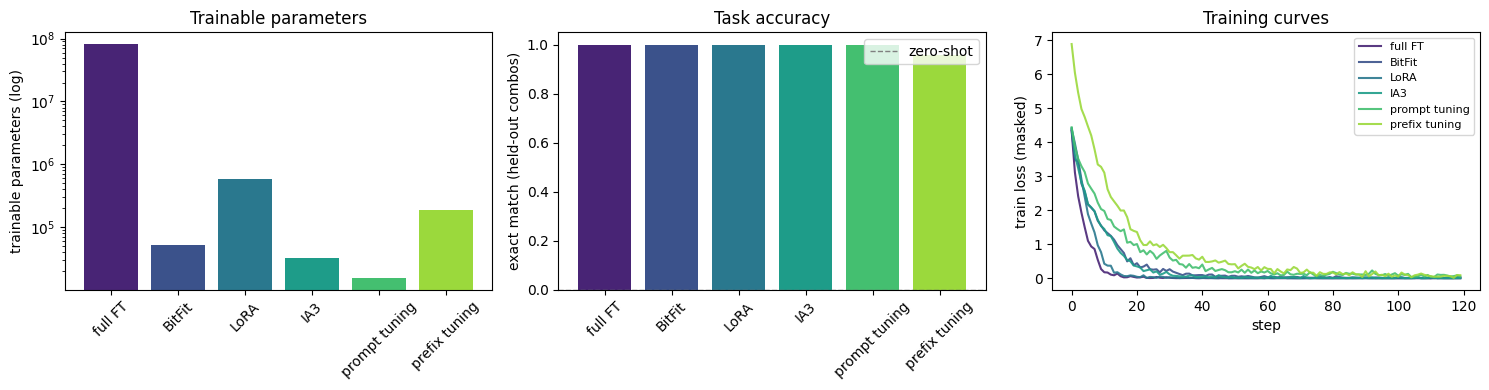

Reading: every method reaches the exact-match ceiling on this deliberately learnable task; the separation shows up in eval loss and convergence speed, while trainable parameters span 4 orders of magnitude.


In [11]:
order = ["full FT", "BitFit", "LoRA", "IA3", "prompt tuning", "prefix tuning"]
print(f"{'method':<15}{'trainable':>12}{'eval loss':>11}{'exact match':>13}{'time':>7}")
for k in ["zero-shot"] + order:
    r = results[k]
    print(f"{k:<15}{r['trainable']:>12,}{r['eval_loss']:>11.4f}{r['em']:>13.2f}{r['time']:>6.0f}s")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(order)))

axes[0].bar(order, [max(results[k]["trainable"], 1) for k in order], color=colors)
axes[0].set_yscale("log")
axes[0].set_ylabel("trainable parameters (log)")
axes[0].set_title("Trainable parameters")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(order, [results[k]["em"] for k in order], color=colors)
axes[1].axhline(results["zero-shot"]["em"], color="gray", ls="--", lw=1, label="zero-shot")
axes[1].set_ylabel("exact match (held-out combos)")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Task accuracy")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

for k, c in zip(order, colors):
    axes[2].plot(results[k]["losses"], label=k, color=c, alpha=0.9)
axes[2].set_xlabel("step"); axes[2].set_ylabel("train loss (masked)")
axes[2].set_title("Training curves")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Reading: every method reaches the exact-match ceiling on this deliberately learnable task; "
      "the separation shows up in eval loss and convergence speed, "
      "while trainable parameters span 4 orders of magnitude.")

## 11. DPO from scratch — swapping the objective, keeping the parameters

Now the other axis. Scenario: our SFT data was scraped from a source where **70% of reports carry a boilerplate tail** ("Stay alert and drive safely at all times!"). SFT treats every training token as equally correct — it cannot express "this response is valid but worse" — so the model learns the majority behavior.

**Preference data can.** We build pairs where *chosen* = clean report, *rejected* = tailed report, and optimize the DPO loss

$$\mathcal{L} = -\log \sigma\left(\beta\left[\log\tfrac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \log\tfrac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}\right]\right)$$

implemented below in ~15 lines. The reference model is a frozen copy of the SFT policy; because our pairs are static (offline DPO), its log-probs are precomputed once.

First, reproduce the contaminated SFT model:

In [12]:
policy = get_peft_model(load_base(), copy.deepcopy(lora_cfg))
print("SFT on 70%-tailed data (LoRA, same recipe as section 6):")
sft_losses = train_sft(policy, train_data, lr=1e-3, tail_prob=0.7)
em0, tail0, gens = evaluate_generation(policy, eval_data)
print(f"pre-DPO: correct-report rate {em0:.2f} | tail rate {tail0:.2f}")
print(f"  sample: {gens[0]!r}")

SFT on 70%-tailed data (LoRA, same recipe as section 6):


  step  30/120  loss 0.0889


  step  60/120  loss 0.0447


  step  90/120  loss 0.0460


  step 120/120  loss 0.0292


pre-DPO: correct-report rate 1.00 | tail rate 1.00
  sample: 'At 14:30 it is 5 degrees and foggy. Stay alert and drive safely at all times!'


In [13]:
def response_logps(model, pairs, tail_flags, bs=BATCH):
    """Sum of response-token log-probs per example (prompt tokens masked out)."""
    out = []
    for i in range(0, len(pairs), bs):
        ids, lab, attn = encode_batch(pairs[i:i + bs], tail_flags[i:i + bs])
        logits = model(input_ids=ids, attention_mask=attn).logits
        lp = torch.log_softmax(logits[:, :-1], dim=-1)
        tgt = lab[:, 1:]
        mask = tgt != -100
        g = torch.gather(lp, 2, tgt.clamp(min=0).unsqueeze(-1)).squeeze(-1)
        out.append((g * mask).sum(-1))
    return torch.cat(out)

# frozen reference = copy of the SFT policy; precompute its log-probs once (offline DPO)
ref = copy.deepcopy(policy)
for p in ref.parameters():
    p.requires_grad_(False)
ref.eval()

pairs = train_data[:96]              # prompts; chosen = clean target, rejected = +TAIL
CHOSEN = [False] * len(pairs)
REJECTED = [True] * len(pairs)
with torch.no_grad():
    ref_w = response_logps(ref, pairs, CHOSEN)
    ref_l = response_logps(ref, pairs, REJECTED)

BETA = 0.1
opt = torch.optim.AdamW([p for p in policy.parameters() if p.requires_grad], lr=5e-5)
rng = random.Random(1)
history = {"step": [0], "em": [em0], "tail": [tail0], "margin": [0.0], "loss": []}

for step in range(1, 61):
    policy.train()
    idx = rng.sample(range(len(pairs)), BATCH)
    chunk = [pairs[i] for i in idx]
    pi_w = response_logps(policy, chunk, [False] * BATCH)   # policy log-probs, chosen
    pi_l = response_logps(policy, chunk, [True] * BATCH)    # policy log-probs, rejected
    margins = BETA * ((pi_w - ref_w[idx]) - (pi_l - ref_l[idx]))
    loss = -F.logsigmoid(margins).mean()                    # the entire DPO loss
    loss.backward(); opt.step(); opt.zero_grad()
    history["loss"].append(loss.item())
    if step % 10 == 0:
        em, tail, gens = evaluate_generation(policy, eval_data)
        history["step"].append(step); history["em"].append(em)
        history["tail"].append(tail); history["margin"].append(margins.mean().item())
        print(f"step {step:2d} | dpo loss {loss.item():.4f} | reward margin {margins.mean().item():+.2f} "
              f"| correct {em:.2f} | tail {tail:.2f} | sample: {gens[0][:50]!r}")

step 10 | dpo loss 0.5345 | reward margin +0.35 | correct 1.00 | tail 0.00 | sample: 'At 14:30 it is 5 degrees and foggy.'


step 20 | dpo loss 0.4028 | reward margin +0.70 | correct 1.00 | tail 0.00 | sample: 'At 14:30 it is 5 degrees and foggy.'


step 30 | dpo loss 0.3086 | reward margin +1.03 | correct 1.00 | tail 0.00 | sample: 'At 14:30 it is 5 degrees and foggy.'


step 40 | dpo loss 0.1919 | reward margin +1.60 | correct 0.12 | tail 0.00 | sample: ''


step 50 | dpo loss 0.0479 | reward margin +3.20 | correct 0.00 | tail 0.00 | sample: ''


step 60 | dpo loss 0.0025 | reward margin +6.48 | correct 0.00 | tail 0.00 | sample: ''


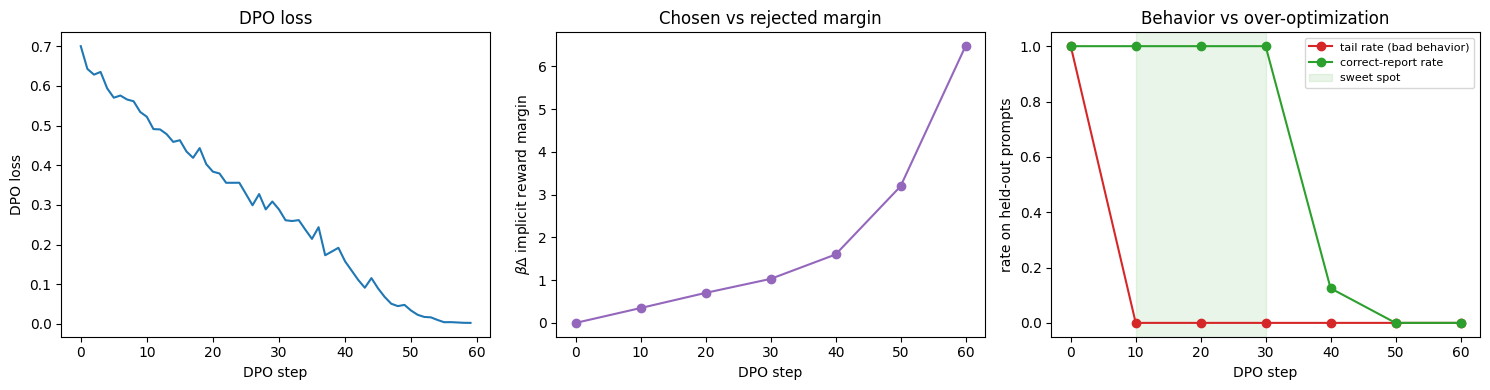

step 30: tail 0.00 (was 1.00), correct 1.00 -- DPO removed the majority behavior without a single corrective demonstration.
step 60: correct 0.00 -- over-optimization: the margin keeps growing while the response itself degrades (survey pitfall #8: too many steps / weak tether).


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["loss"], color="tab:blue")
axes[0].set_xlabel("DPO step"); axes[0].set_ylabel("DPO loss")
axes[0].set_title("DPO loss")

axes[1].plot(history["step"], history["margin"], "o-", color="tab:purple")
axes[1].set_xlabel("DPO step"); axes[1].set_ylabel(r"$\beta \Delta$ implicit reward margin")
axes[1].set_title("Chosen vs rejected margin")

axes[2].plot(history["step"], history["tail"], "o-", color="tab:red", label="tail rate (bad behavior)")
axes[2].plot(history["step"], history["em"], "o-", color="tab:green", label="correct-report rate")
axes[2].axvspan(10, 30, color="tab:green", alpha=0.1, label="sweet spot")
axes[2].set_xlabel("DPO step"); axes[2].set_ylabel("rate on held-out prompts")
axes[2].set_ylim(-0.05, 1.05)
axes[2].set_title("Behavior vs over-optimization")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

i = history["step"].index(30)
print(f"step 30: tail {history['tail'][i]:.2f} (was {tail0:.2f}), correct {history['em'][i]:.2f} -- "
      f"DPO removed the majority behavior without a single corrective demonstration.")
print(f"step 60: correct {history['em'][-1]:.2f} -- over-optimization: the margin keeps growing "
      f"while the response itself degrades (survey pitfall #8: too many steps / weak tether).")

## Takeaways

1. **Six methods spanning 4 orders of magnitude in trainable parameters all solved this task.** Full FT (82M), LoRA (590K), prefix (184K), BitFit (51K), IA3 (32K) and prompt tuning (15K) all reached (near-)perfect exact match -- evidence the task sat well within the base model's reach (the BitFit-as-diagnostic point from the survey). The ranking survives in the margins: eval loss orders full FT / LoRA < IA3 < BitFit < prompt < prefix, and on harder tasks these capacity gaps reappear as accuracy gaps -- at scale, LoRA-class methods track full FT while soft prompts need larger base models to keep up.
2. **Learning rate is method-specific, not optional.** The same loop needed lr 5e-5 (full FT) to 3e-2 (prompt tuning) — a 600x spread. Copying full-FT hyperparameters into a PEFT config silently cripples it.
3. **Prompt masking + EOS discipline are load-bearing.** Loss was computed only on response tokens, and every target ended in EOS — remove either and this task visibly degrades (see the survey's SFT section).
4. **SFT learns whatever the data majority does; DPO expresses "valid but worse."** The 70%-tailed SFT model produced boilerplate on 100% of prompts. Sixty lines of from-scratch DPO — two frozen-reference forward passes and a log-sigmoid — removed it completely by step 10-30 while keeping reports correct.
5. **Preference optimization over-optimizes if untethered.** Past the sweet spot the implicit reward margin kept climbing while generation quality collapsed — the same dynamic as RLHF reward hacking, and why beta, step count, and a held-out behavioral eval matter as much in DPO as in PPO.
6. **Method choice is two orthogonal decisions**: which objective (SFT vs preference) fixes *what the model learns*; which parameter method (full/LoRA/additive/selective) fixes *what it costs*. See the survey's decision guide (section 9).